In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

base_path = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

# Region
LAT_MIN, LAT_MAX = 25, 45
LON_MIN, LON_MAX = -50, -30

In [2]:
# Flat-linear model
def flat_then_linear(x, c, m, x_break):
    return np.where(
        x < x_break,
        c,
        c + m * (x - x_break)
    )

In [3]:
def flat_piecewise_variable_analysis(
    variable_token,
    variable_label,
    units,
    start_year=1958,
    end_year=2023,
    break_guess=1980
):

    # Find files
    files = sorted(base_path.rglob(f"*{variable_token}*.nc"))
    print(f"\nFound {len(files)} files for {variable_label}")

    records = []

    for f in files:
        try:
            # Extract year/month
            match = re.search(
                rf"ORAS5_(\d{{4}})_(\d{{2}}).*{variable_token}",
                f.name
            )

            if match is None:
                continue

            year = int(match.group(1))
            month = int(match.group(2))

            ds = xr.open_dataset(f)

            # First variable in dataset
            var_name = list(ds.data_vars)[0]
            var = ds[var_name]

            # Remove depth dimension if present
            for depth_dim in ["deptht", "depth", "lev"]:
                if depth_dim in var.dims:
                    var = var.isel({depth_dim: 0})

            # Coordinates
            if "nav_lat" in ds:
                lat = ds["nav_lat"]
                lon = ds["nav_lon"]
            elif "latitude" in ds:
                lat = ds["latitude"]
                lon = ds["longitude"]
            else:
                print(f"Skipping {f.name}: no recognised lat/lon coordinates")
                continue

            # Convert longitude if needed
            lon = xr.where(lon > 180, lon - 360, lon)

            # Box mask
            box_mask = (
                (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                (lon >= LON_MIN) & (lon <= LON_MAX)
            )

            # Apply mask
            var_box = var.where(box_mask)

            # Convert SST to C if needed
            if variable_token == "sst":
                if float(var_box.mean(skipna=True)) > 100:
                    var_box = var_box - 273.15

            # Mean over box
            monthly_mean = float(var_box.mean(skipna=True))

            records.append({
                "year": year,
                "month": month,
                variable_label: monthly_mean
            })

            ds.close()

        except Exception as e:
            print(f"Skipping {f.name}: {e}")

    # Dataframe
    df = pd.DataFrame(records)

    annual_df = (
        df
        .groupby("year", as_index=False)[variable_label]
        .mean()
        .sort_values("year")
    )

    # Year range
    annual_df = annual_df[
        (annual_df["year"] >= start_year) &
        (annual_df["year"] <= end_year)
    ]

    # Remove NaNs and unrealistic fill values (temporarily fixes the massive spikes we saw)
    annual_df = annual_df.replace([np.inf, -np.inf], np.nan)
    annual_df = annual_df.dropna()

    annual_df = annual_df[
        np.abs(annual_df[variable_label]) < 1e10
    ]

    years_clean = annual_df["year"].values.astype(float)
    values_clean = annual_df[variable_label].values.astype(float)

    print(annual_df)

    # Initial parameter guesses
    c_guess = np.mean(values_clean[years_clean < break_guess])
    m_guess = 0.01

    p0 = [c_guess, m_guess, break_guess]

    # Parameter bounds
    lower_bounds = [
        np.min(values_clean) - abs(np.min(values_clean)),
        -np.inf,
        start_year + 5
    ]

    upper_bounds = [
        np.max(values_clean) + abs(np.max(values_clean)),
        np.inf,
        end_year - 5
    ]

    # Fit model
    popt, pcov = curve_fit(
        flat_then_linear,
        years_clean,
        values_clean,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=100000
    )

    c_fit, m_fit, break_fit = popt

    # Errors
    perr = np.sqrt(np.diag(pcov))
    c_err, m_err, break_err = perr

    # Predictions
    y_hat = flat_then_linear(years_clean, c_fit, m_fit, break_fit)

    # Residuals
    residuals = values_clean - y_hat
    rss = np.sum(residuals**2)
    tss = np.sum((values_clean - np.mean(values_clean))**2)
    r2 = 1 - rss / tss

    print(f"\nOptimised breakpoint year: {break_fit:.2f} ± {break_err:.2f}")
    print(f"Flat baseline: {c_fit:.5f} ± {c_err:.5f} {units}")
    print(f"Post-break slope: {m_fit:.5f} ± {m_err:.5f} {units}/year")
    print(f"R²: {r2:.4f}")

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        years_clean,
        values_clean,
        linewidth=1.5,
        label=f"Observed {variable_label}"
    )

    plt.plot(
        years_clean,
        y_hat,
        linewidth=2.5,
        label="Flat-then-linear fit"
    )

    plt.axvline(
        break_fit,
        linestyle="--",
        alpha=0.8,
        label=f"Breakpoint = {break_fit:.1f}"
    )

    plt.title(f"Flat-Then-Linear Fit on Annual Mean {variable_label}")
    plt.xlabel("Year")
    plt.ylabel(f"{variable_label} ({units})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return annual_df, popt, pcov


Found 816 files for SST
    year        SST
0   1958  20.584044
1   1959  20.410537
2   1960  20.945526
3   1961  20.938600
4   1962  20.656470
..   ...        ...
61  2019  21.102062
62  2020  21.271212
63  2021  21.413530
64  2022  21.270770
65  2023  21.454871

[66 rows x 2 columns]

Optimised breakpoint year: 1982.00 ± 4.42
Flat baseline: 20.49287 ± 0.04258 °C
Post-break slope: 0.01812 ± 0.00281 °C/year
R²: 0.5913


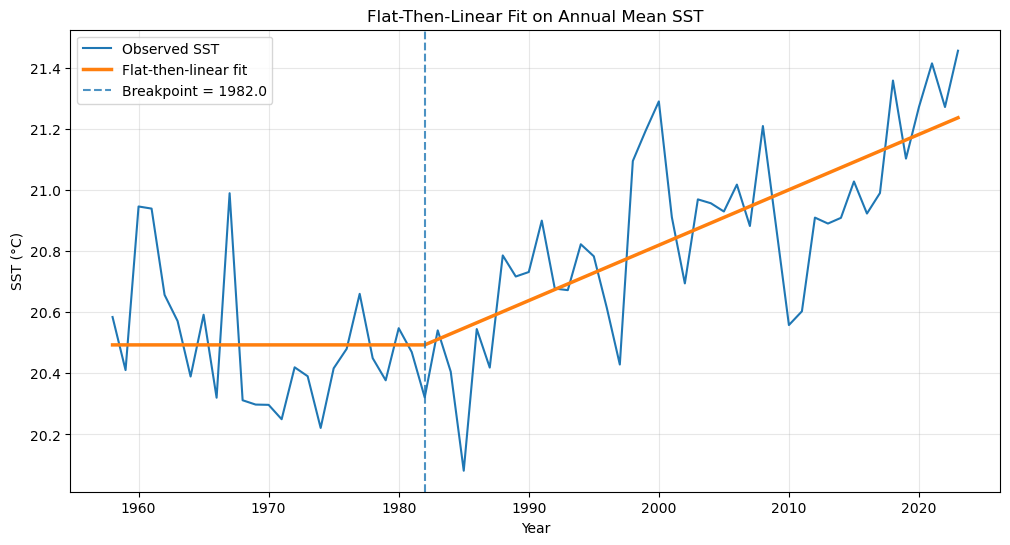

In [4]:
# SST
sst_df, sst_fit, sst_cov = flat_piecewise_variable_analysis(
    variable_token="sst",
    variable_label="SST",
    units="°C",
    break_guess=1975
)


Found 791 files for Salinity
    year   Salinity
0   1958  36.332911
1   1959  36.386271
2   1960  36.406404
3   1961  36.472236
4   1962  36.451410
..   ...        ...
56  2014  36.440841
57  2015  36.432220
58  2016  36.451520
59  2017  36.507505
60  2018  36.538486

[61 rows x 2 columns]

Optimised breakpoint year: 1973.00 ± 9.96
Flat baseline: 36.41294 ± 0.01609 PSU
Post-break slope: 0.00250 ± 0.00071 PSU/year
R²: 0.2752


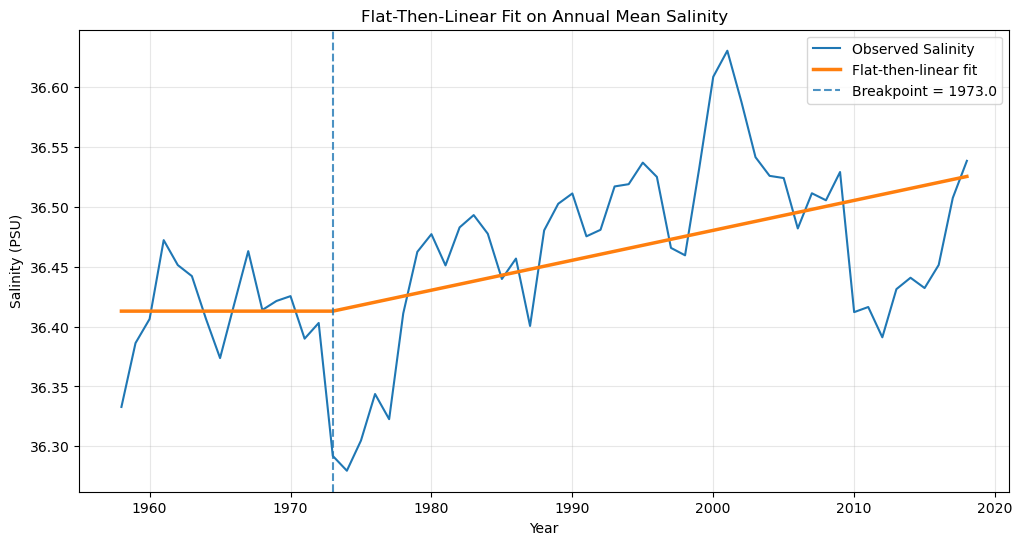

In [5]:
# Salinity
sal_df, sal_fit, sal_cov = flat_piecewise_variable_analysis(
    variable_token="so_salinity",
    variable_label="Salinity",
    units="PSU",
    break_guess=1975
)


Found 794 files for V Current
Skipping ORAS5_1979_02_v_meridional_boxed.nc: no recognised lat/lon coordinates
    year  V Current
0   1958  -0.001438
1   1959  -0.002055
2   1960  -0.002936
3   1961  -0.002971
4   1962  -0.002158
..   ...        ...
56  2014  -0.002454
57  2015  -0.002272
58  2016  -0.002088
59  2017  -0.002897
60  2018  -0.003811

[61 rows x 2 columns]

Optimised breakpoint year: 1965.00 ± 80.15
Flat baseline: -0.00261 ± 0.00034 m/s
Post-break slope: -0.00001 ± 0.00001 m/s/year
R²: 0.0094


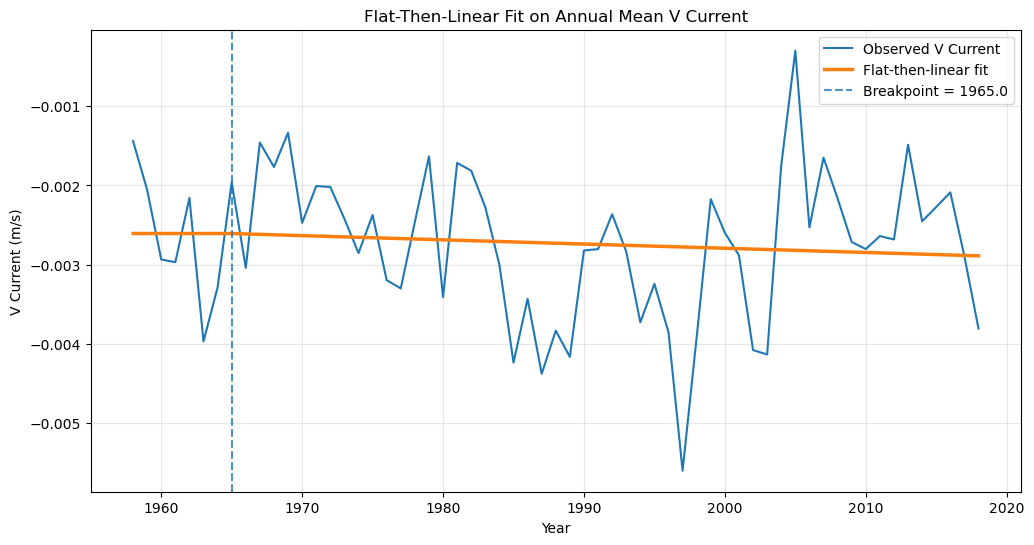

In [6]:
# V current
v_df, v_fit, v_cov = flat_piecewise_variable_analysis(
    variable_token="v_meridional",
    variable_label="V Current",
    units="m/s",
    break_guess=1975
)